In [7]:
# 74 students - marks and subject-wise attendance analysis using Numpy

In [13]:
import numpy as np
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
# Step 8: Load CSV Data
# In this step, we load the exported Google Sheet CSV file using NumPy
# Data sets columns 0-Reg.no, 1-Name,2- Marks, 3-actual attendance , 4-attedendance percerntage
data = np.genfromtxt(
    "Student_data.csv",
    delimiter=",",
    dtype=str,
    skip_header=1
)

# print("Data shape:", data.shape)
# print(data[:5])

In [ ]:
# Create subject array
subjects = np.array(["TOC", "AIML", "DBMS", "AL", "IOS", "EVS"])
subjects

array(['TOC', 'AIML', 'DBMS', 'AL', 'IOS', 'EVS'], dtype='<U4')

In [ ]:
# arrange the shape
reg_no = data[:,0]
student_name = data [:,1]
print ("Reg no Shape:", reg_no.shape)
print ("Student Name Shape:", student_name.shape)

Reg no Shape: (74,)
Student Name Shape: (74,)


In [ ]:
# separate Marks Column and Marks columns are 2,5,8,11,14,17
marks_raw = data[:,[2,5,8,11,14,17]]
print ("Marks Raw Shape:", marks_raw.shape)
print (marks_raw[:1])

Marks Raw Shape: (74, 6)
[['46' '0' '0' '68' '48' '57']]


In [ ]:
# separate attendance Count Column and attendance columns are 3,6,9,12,15,18
attendance_count_raw=data[:,[3,6,9,12,15,18]]
print ("Attendance Raw Shape:", attendance_count_raw.shape)
print (attendance_count_raw[:1])

Attendance Raw Shape: (74, 6)
[['24' '35' '23' '35' '23' '18']]


In [ ]:
# Combine together 
attendance_percentage_raw = data[:, [4,7,10,13,16,19]]
print ("Subjects:", subjects)
print ("Reg No Shape", reg_no.shape)
print ("Name Shape", student_name.shape)
print ("Marks Raw Shape:", marks_raw.shape)
print ("Attendance Raw Shape:", attendance_count_raw.shape)
print ("Attendance Percentage Shape:", attendance_percentage_raw.shape)

print ("\nFirst 5 Names")
print (student_name[:5],)

print("\nFirst 5 marks raw:")
print(marks_raw[:5])

print("\nFirst 5 attendance count raw:")
print(attendance_count_raw[:5])

print("\nFirst 5 attendance percent raw:")
print(attendance_percentage_raw[:5])


Subjects: ['TOC' 'AIML' 'DBMS' 'AL' 'IOS' 'EVS']
Reg No Shape (74,)
Name Shape (74,)
Marks Raw Shape: (74, 6)
Attendance Raw Shape: (74, 6)
Attendance Percentage Shape: (74, 6)

First 5 Names
['ABINAYA V' 'ANISHRAM.K' 'ARAVINDHAN C' 'ARIHEESWARI R' 'ARUNPANDIYAN S']

First 5 marks raw:
[['46' '0' '0' '68' '48' '57']
 ['0' '0' '0' '0' '0' '0']
 ['36' '0' '26' '52' '36' '0']
 ['28' '64' '72' '57' '62' '78']
 ['0' '56' '18' '42' '0' '6']]

First 5 attendance count raw:
[['24' '35' '23' '35' '23' '18']
 ['1' '1' '0' '0' '0' '0']
 ['21' '32' '22' '33' '22' '18']
 ['17' '30' '17' '29' '17' '13']
 ['5' '10' '8' '29' '10' '2']]

First 5 attendance percent raw:
[['85.71%' '92.11%' '92.00%' '92.11%' '92.00%' '100.00%']
 ['3.57%' '2.63%' '0.00%' '0.00%' '0.00%' '0.00%']
 ['75.00%' '84.21%' '88.00%' '86.84%' '88.00%' '100.00%']
 ['60.71%' '78.95%' '68.00%' '76.32%' '68.00%' '72.22%']
 ['17.86%' '26.32%' '32.00%' '76.32%' '40.00%' '11.11%']]


In [ ]:
# Clean Marks and Attendance Percentage Values
# just befor the array values are in string format because we loaded the csv using dtype str in the define function to load csv
# now we will convert into integer or other relevant data types
# marks_raw = marks
# attendance_count_raw = attendance_count 
# before that we ensure that no A,AB or OD 
# Convert to Numeric using astype

marks_clean = np.where(
    (marks_raw == "AB") | (marks_raw == "A") | (marks_raw == "OD"),
    "0",
    marks_raw
)

marks = marks_clean.astype(np.int16)

attendance_count = attendance_count_raw.astype(np.int16)

print (marks.shape)
print (attendance_count.shape)



(74, 6)
(74, 6)


In [ ]:
# for the percentage conversion we need to remove the % from the data
# using below and change to float
attendance_percent_no_symbol = np.char.replace(attendance_percentage_raw, "%", "")

attendance_percent = attendance_percent_no_symbol.astype(np.float16)

print("Attendance percent shape:", attendance_percent.shape)
print(attendance_percent[:5])

Attendance percent shape: (74, 6)
[[ 85.7   92.1   92.    92.1   92.   100.  ]
 [  3.57   2.63   0.     0.     0.     0.  ]
 [ 75.    84.2   88.    86.8   88.   100.  ]
 [ 60.72  78.94  68.    76.3   68.    72.25]
 [ 17.86  26.31  32.    76.3   40.    11.11]]


In [ ]:
print ("Reg no", reg_no.dtype)
print ("Name", student_name.dtype)
print ("Marks", marks.dtype)
print ("Attendance", attendance_count.dtype)
print ("Perentage", attendance_percent.dtype)

Reg no <U18
Name <U18
Marks int16
Attendance int16
Perentage float16


In [ ]:
# 1. Total marks of each student
# 2. Average marks of each student
# 3. Subject-wise average marks
# 4. Highest and lowest marks in each subject

In [ ]:
# Total Marks of each Student
total_marks = np.sum (marks, axis=1)
average_marks = np.mean (marks,axis=1)
print (total_marks.shape)
print (total_marks[:10])
print (average_marks.shape)
print (average_marks[:10])


(74,)
[219   0 150 361 122 162  42 330 108  97]
(74,)
[36.5         0.         25.         60.16666667 20.33333333 27.
  7.         55.         18.         16.16666667]


In [ ]:
# Student Average Mark
student_average_marks = np.mean (marks,axis=1)
print ("Student Average:", average_marks.shape)
print (np.round(average_marks[:10],2 ))

Student Average: (74,)
[36.5   0.   25.   60.17 20.33 27.    7.   55.   18.   16.17]


In [ ]:
# Subject Average marks
subject_wise_average = np.mean(marks,axis=0)
print ("Subject Wise Average Marks:")
for i in range(len(subjects)):
    print (subjects[i], ":", round(subject_wise_average[i],2))

Subject Wise Average Marks:
TOC : 27.43
AIML : 43.14
DBMS : 34.55
AL : 38.19
IOS : 34.93
EVS : 37.49


In [ ]:
# Find subject wise lowest and highest  
# Max and Min Funtion
subject_highest_marks = np.max(marks, axis=0)

print("Subject-wise average marks:")
for i in range(len(subjects)):
    print(subjects[i], ":", round(subject_highest_marks[i], 2))


Subject-wise average marks:
TOC : 86
AIML : 96
DBMS : 84
AL : 82
IOS : 76
EVS : 96


In [ ]:
subject_minimum_marks = np.min(marks, axis=0)

print("Subject-wise average marks:")
for i in range(len(subjects)):
    print(subjects[i], ":", round(subject_minimum_marks[i], 2))

Subject-wise average marks:
TOC : 0
AIML : 0
DBMS : 0
AL : 0
IOS : 0
EVS : 0


In [ ]:
# Subjectwise Pass count 
# passing mark 50 


subject_pass_count = np.sum(marks >= 50, axis=0)
print ("Subject Wise Pass Count:")
for i in range (len(subjects)):
    print (subjects[i], ":", subject_pass_count[i])


# studentwise fail count

subject_fail_count = np.sum(marks < 50, axis=0)
print ("Subject Wise fail Count:")
for i in range (len(subjects)):
    print (subjects[i], ":", subject_fail_count[i])  

print (subject_pass_count + subject_fail_count)

Subject Wise Pass Count:
TOC : 10
AIML : 44
DBMS : 35
AL : 34
IOS : 28
EVS : 37
Subject Wise fail Count:
TOC : 64
AIML : 30
DBMS : 39
AL : 40
IOS : 46
EVS : 37
[74 74 74 74 74 74]


In [ ]:
# Here to Print the student wise passed and failed count 
# Pass Mark = 50
student_pass_count = np.sum(marks >= 50, axis=1)
student_fail_count = np.sum(marks < 50, axis=1)
for i in range (len(student_name)):
    print(
        reg_no[i],
        student_name [i],
        "Passed:", student_pass_count [i],
        "Failed:", student_fail_count [i]
    )

912024104001 ABINAYA V Passed: 2 Failed: 4
912024104002 ANISHRAM.K Passed: 0 Failed: 6
912024104003 ARAVINDHAN C Passed: 1 Failed: 5
912024104004 ARIHEESWARI R Passed: 5 Failed: 1
912024104005 ARUNPANDIYAN S Passed: 1 Failed: 5
912024104006 ASHWIN J Passed: 1 Failed: 5
912024104007 ATHIMURUGAN P Passed: 0 Failed: 6
912024104008 AZHAGU NAGAJOTHI A Passed: 5 Failed: 1
912024104009 BHAGAVATH SINGH M Passed: 0 Failed: 6
912024104010 CHANDRU MADAVAN K Passed: 1 Failed: 5
912024104011 CHITHANATHAN V Passed: 1 Failed: 5
912024104012 DHANANJEYAN N Passed: 1 Failed: 5
912024104013 DHARSHINI PRIYA R Passed: 4 Failed: 2
912024104014 DEETCHANA S Passed: 5 Failed: 1
912024104016 GOWTHAM U Passed: 2 Failed: 4
912024104017 HARINI A Passed: 4 Failed: 2
912024104018 HARINI P Passed: 5 Failed: 1
912024104019 HEMA SRI C Passed: 5 Failed: 1
912024104020 JOUSUA EBINEZER M Passed: 4 Failed: 2
912024104021 KAMATCHI S Passed: 0 Failed: 6
912024104022 KARTHIKEYAN N K Passed: 0 Failed: 6
912024104023 KAVIYA T P

In [ ]:
# Overall class result
overall_pass = np.sum (student_fail_count == 0)
overall_fail = np.sum (student_fail_count > 0)
print ("Overall Pass", overall_pass)
print ("Overall Fail", overall_fail)

Overall Pass 5
Overall Fail 69


In [ ]:
# Attendance Shortage Analysis
# Attendance Eligibility rule (75% and above)
attendance_status = attendance_percent >= 75
student_attendance_ok_count = np.sum(attendance_status, axis =1)
student_shortage_count = np.sum(attendance_percent < 75, axis =1)
attendance_result = np.where(student_shortage_count == 0, "Eligible", "Shortage")
attendance_eligible_count = np.sum(student_shortage_count == 0)
attendance_shortage_count = np.sum(student_shortage_count > 0)
#print(student_attendance_ok_count + student_shortage_count)
#print(attendance_eligible_count + attendance_shortage_count)
print("Attendance Eligible Students:", attendance_eligible_count)
print("Attendance Shortage Students:", attendance_shortage_count)
print("Total Students:", attendance_eligible_count + attendance_shortage_count)
for i in range(10):
    print(
        reg_no[i],
        student_name[i],
        "OK Subjects:", student_attendance_ok_count[i],
        "Shortage Subjects:", student_shortage_count[i],
        "Result:", attendance_result[i]
    )

Attendance Eligible Students: 27
Attendance Shortage Students: 47
Total Students: 74
912024104001 ABINAYA V OK Subjects: 6 Shortage Subjects: 0 Result: Eligible
912024104002 ANISHRAM.K OK Subjects: 0 Shortage Subjects: 6 Result: Shortage
912024104003 ARAVINDHAN C OK Subjects: 6 Shortage Subjects: 0 Result: Eligible
912024104004 ARIHEESWARI R OK Subjects: 2 Shortage Subjects: 4 Result: Shortage
912024104005 ARUNPANDIYAN S OK Subjects: 1 Shortage Subjects: 5 Result: Shortage
912024104006 ASHWIN J OK Subjects: 3 Shortage Subjects: 3 Result: Shortage
912024104007 ATHIMURUGAN P OK Subjects: 0 Shortage Subjects: 6 Result: Shortage
912024104008 AZHAGU NAGAJOTHI A OK Subjects: 2 Shortage Subjects: 4 Result: Shortage
912024104009 BHAGAVATH SINGH M OK Subjects: 6 Shortage Subjects: 0 Result: Eligible
912024104010 CHANDRU MADAVAN K OK Subjects: 1 Shortage Subjects: 5 Result: Shortage


In [ ]:
subject_highest_marks

array([86, 96, 84, 82, 76, 96], dtype=int16)

In [ ]:
highest_marks_index = np.argmax (marks,axis =0)
highest_marks_index 

array([47, 39, 47, 42, 47, 13])

In [ ]:
# Get Topper details
topper_reg_no =  reg_no [highest_marks_index]
topper_names = student_name [highest_marks_index]
for i in range (len(subjects)):
    print (
        subjects[i],
        topper_reg_no [i],
        topper_names [i],
        subject_highest_marks [i]
    )


TOC 912024104050 RAGAVI P 86
AIML 912024104042 NIVETHA B 96
DBMS 912024104050 RAGAVI P 84
AL 912024104045 PRADEEPA M 82
IOS 912024104050 RAGAVI P 76
EVS 912024104014 DEETCHANA S 96


In [ ]:
# find the toppers list
ranking_index = np.argsort (total_marks) [::-1]
# Display top 10 students
print ("Top 10 student Ranking")
print ("-" *50)
for i in range(10):
    idx = ranking_index[i]

    print(
        i + 1,
        "| Reg No:", reg_no[idx],
        "| Name:", student_name[idx],
        "| Total:", total_marks[idx],
        "| Average:", round(average_marks [idx],2)
    )

Top 10 student Ranking
--------------------------------------------------
1 | Reg No: 912024104050 | Name: RAGAVI P | Total: 496 | Average: 82.67
2 | Reg No: 912024104042 | Name: NIVETHA B | Total: 466 | Average: 77.67
3 | Reg No: 912024104045 | Name: PRADEEPA M | Total: 434 | Average: 72.33
4 | Reg No: 912024104035 | Name: MENAGGA A | Total: 419 | Average: 69.83
5 | Reg No: 912024104051 | Name: RAJALAKSHMI K | Total: 417 | Average: 69.5
6 | Reg No: 912024104023 | Name: KAVIYA T | Total: 414 | Average: 69.0
7 | Reg No: 912024104072 | Name: VIJAYADHARSHINI P | Total: 414 | Average: 69.0
8 | Reg No: 912024104070 | Name: VETHIKA G | Total: 406 | Average: 67.67
9 | Reg No: 912024104062 | Name: SHARMIKA M | Total: 381 | Average: 63.5
10 | Reg No: 912024104014 | Name: DEETCHANA S | Total: 381 | Average: 63.5


In [ ]:
student_grade = []
for i in range(len(student_name)):

    if student_fail_count [i] >0 :
        grade = "U"
    else:
        if average_marks [i] >= 90:
            grade = "O"
        elif average_marks [i] >= 80:
            grade = "A+"
        elif average_marks [i] >= 70:
            grade = "A"
        elif average_marks [i] >= 60:
            grade = "B"
        else:
            grade = "C"
    student_grade.append(grade)

    print(
        "|", reg_no[i],
        "|", student_name[i],
        "|", student_fail_count[i],
        "|", round(average_marks [i],2),
        "|", grade
    )
student_grade = np.array(student_grade)


| 912024104001 | ABINAYA V | 4 | 36.5 | U
| 912024104002 | ANISHRAM.K | 6 | 0.0 | U
| 912024104003 | ARAVINDHAN C | 5 | 25.0 | U
| 912024104004 | ARIHEESWARI R | 1 | 60.17 | U
| 912024104005 | ARUNPANDIYAN S | 5 | 20.33 | U
| 912024104006 | ASHWIN J | 5 | 27.0 | U
| 912024104007 | ATHIMURUGAN P | 6 | 7.0 | U
| 912024104008 | AZHAGU NAGAJOTHI A | 1 | 55.0 | U
| 912024104009 | BHAGAVATH SINGH M | 6 | 18.0 | U
| 912024104010 | CHANDRU MADAVAN K | 5 | 16.17 | U
| 912024104011 | CHITHANATHAN V | 5 | 23.33 | U
| 912024104012 | DHANANJEYAN N | 5 | 27.67 | U
| 912024104013 | DHARSHINI PRIYA R | 2 | 51.0 | U
| 912024104014 | DEETCHANA S | 1 | 63.5 | U
| 912024104016 | GOWTHAM U | 4 | 28.0 | U
| 912024104017 | HARINI A | 2 | 51.5 | U
| 912024104018 | HARINI P | 1 | 56.33 | U
| 912024104019 | HEMA SRI C | 1 | 54.0 | U
| 912024104020 | JOUSUA EBINEZER M | 2 | 54.0 | U
| 912024104021 | KAMATCHI S | 6 | 7.5 | U
| 912024104022 | KARTHIKEYAN N K | 6 | 0.0 | U
| 912024104023 | KAVIYA T | 0 | 69.0 | B
|

In [ ]:
# Grade Distribution analysis
o_count = np.sum(student_grade == "O")
a_count = np.sum(student_grade == "A")
ap_count = np.sum(student_grade == "A+")
b_count = np.sum(student_grade == "B")
c_count = np.sum(student_grade == "C")
u_count = np.sum(student_grade == "U")
#print 
print (o_count)
print (a_count)
print (ap_count)
print (b_count)
print (c_count)
print (d_count)
print (u_count)

0
1
1
3
0


NameError: name 'd_count' is not defined

In [ ]:
for i in range(len(student_name)):

    if student_fail_count[i] == 0 and average_marks[i] >= 50:

        print(
            student_name[i],
            average_marks[i]
        )

KAVIYA T 69.0
NIVETHA B 77.66666666666667
RAGAVI P 82.66666666666667
RAJALAKSHMI K 69.5
VETHIKA G 67.66666666666667


In [ ]:
# Now all the analysis is done and we can export the results to a new CSV file for further use or reporting
# Final report can contain:
# Reg_No, Student_Name, Total_Marks, Average_Marks, Passed_Subjects, Failed_Subjects, Attendance_Result
# Final Eligibility (Based on Marks and Attendance), Grade, Academic Result (Pass/Fail)

In [ ]:
overall_result = np.where(
    student_fail_count == 0,
    "Pass",
    "Fail"
)

In [ ]:
final_eligibility = np.where(
    (overall_result == "Pass") &
    (attendance_result == "Eligible"),
    "Eligible",
    "Not Eligible"
)

In [ ]:

average_marks_rounded = np.round(average_marks, 2)
final_report = np.column_stack((reg_no, student_name, total_marks, 
                 average_marks_rounded, student_pass_count, 
                 student_fail_count, overall_result,attendance_result, student_grade, 
                 final_eligibility))
print (final_report.shape)

(74, 10)


In [ ]:
# Create header for the final report
header = (
    "Reg_No,Student_Name,Total_Marks,"
    "Average_Marks,Passed_Subjects,"
    "Failed_Subjects,Overall_Result,"
    "Attendance_Result,Final_Eligibility,"
    "Grade"
)


In [ ]:
np.savetxt(
    "Final_Report.csv",
    final_report,
    delimiter=",",
    fmt="%s",
    header=header,
    comments=""
)

In [ ]:
# Mathplotlib Visualization
# 1. Pass vs Fail chart 2. Grade distribution chart 3. Subject average marks chart 4. Attendance eligibility chart
# Will learn matplotlib, bar charts, pie charts, data visualization, presentation-ready analytics


Matplotlib imported successfully


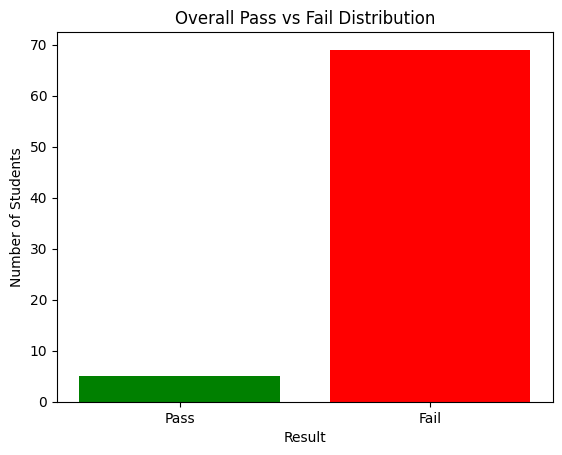

In [ ]:
result_labels = ["Pass", "Fail"]
result_values = [overall_pass, overall_fail]
plt.bar(result_labels, result_values, color=["green", "red"])
plt.xlabel("Result")
plt.ylabel("Number of Students")
plt.title("Overall Pass vs Fail Distribution")
plt.show()


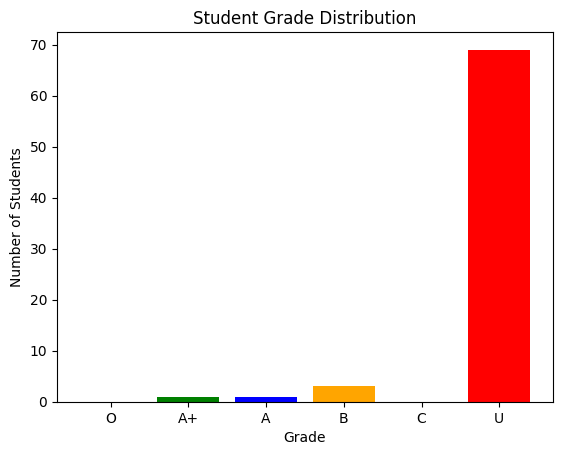

In [ ]:
# Grade distribution chart
grade_labels = ["O", "A+", "A", "B", "C", "U"]
grade_values = [o_count, ap_count, a_count, b_count, c_count, u_count]
plt.bar(grade_labels, grade_values, color=["Gold","Green", "Blue", "Orange", "Purple", "Red"])
plt.xlabel("Grade")
plt.ylabel("Number of Students")
plt.title("Student Grade Distribution")
plt.show()



[27.43243243 43.13513514 34.55405405 38.18918919 34.93243243 37.48648649]


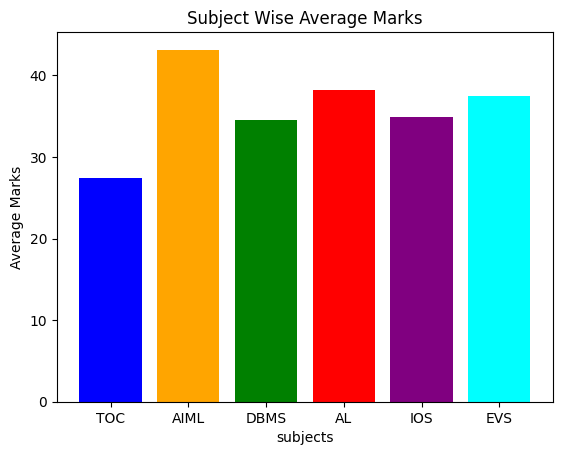

In [ ]:
# Subject Average Marks Viualization
# Visualize average marks of all subjects using bar chart
# print (subjects)
print (subject_wise_average)
plt.bar(subjects, subject_wise_average, color = ["blue", "orange", "green", "red", "purple", "cyan"])
plt.xlabel("subjects")
plt.ylabel("Average Marks")
plt.title("Subject Wise Average Marks")
plt.show()



In [9]:
#  we will visualize the attendance eligibility ditribution using a pie chart
# We have 2 categories overall_pass and overall_fail
# We need to create labels  Pass and Fail
# We use to create plt.pie function 
# Important parameters to learn:
# labels =	Slice labels
# autopct =	Percentage display
# startangle =	Rotate chart
# shadow =	Add shadow
# To add a title use plt.title function
# To show use plt.show function
# Expeected output is Pass percentage and Fail Percentage
plt.pie(
    [overall_pass, overall_fail],
    labels=["Pass","Fail"]
    )



NameError: name 'plt' is not defined